# ARC-LeWM: decode-by-planning JEPA, meta-trained on the ARC public train split
Spec: docs/superpowers/specs/2026-06-09-arc-lewm-design.md
LeWM methods kept verbatim: end-to-end (no EMA / no stop-grad), loss = pred MSE + 0.09*SIGReg, AdaLN predictor, inference = latent-cost optimization (no decoder).
Flagged deviation: K=16 register tokens instead of single CLS (validated by Gate L3).

In [1]:
import json, math, os, random, copy, time
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from einops import rearrange, repeat
import matplotlib.pyplot as plt

torch.manual_seed(0); np.random.seed(0); random.seed(0)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MAX_HW = 30; NUM_COLORS = 10; PAD_ID = 10; VOCAB = 11
D = 192          # LeWM embed_dim
K = 16           # register tokens (flagged deviation from single CLS)
ND_MAX = 4       # max demo pairs per episode
LAM = 0.09       # LeWM sigreg weight
CKPT = Path("data/arc_lewm.pt")
print("device:", DEVICE, "| torch:", torch.__version__)

device: cuda | torch: 2.8.0+cu128


In [2]:
ARC_DIR = Path("data/arc")

def load_arc_split(split):
    """Return dict task_id -> {'train': [(in,out),...], 'test': [(in,out),...]}."""
    out = {}
    for p in sorted((ARC_DIR / "data" / split).glob("*.json")):
        d = json.loads(p.read_text())
        out[p.stem] = {
            "train": [(np.array(e["input"], np.uint8), np.array(e["output"], np.uint8)) for e in d["train"]],
            "test":  [(np.array(e["input"], np.uint8), np.array(e["output"], np.uint8)) for e in d["test"]],
        }
    return out

TRAIN_TASKS = load_arc_split("training")
EVAL_TASKS  = load_arc_split("evaluation")
assert len(TRAIN_TASKS) == 400 and len(EVAL_TASKS) == 400
print("OK: 400 train / 400 eval tasks")

OK: 400 train / 400 eval tasks


## GPU cache + episodic sampler — Gate L0

In [3]:
def pad30(g):
    c = np.full((MAX_HW, MAX_HW), PAD_ID, np.uint8)
    c[:g.shape[0], :g.shape[1]] = g
    return c

def dihedral_variants(g):
    # 8 symmetries: rot k=0..3, each plus a left-right flip
    vs = []
    for k in range(4):
        r = np.rot90(g, k)
        vs.append(r); vs.append(np.fliplr(r))
    return vs

def build_cache(tasks):
    """GPU cache: grids (N,8,30,30) uint8, shapes (N,8,2) long, idx task->pair index lists."""
    grids, shapes, idx = [], [], {}
    def add(g):
        vs = dihedral_variants(g)
        grids.append(np.stack([pad30(v) for v in vs]))
        shapes.append(np.array([v.shape for v in vs], np.int64))
        return len(grids) - 1
    for tid, t in tasks.items():
        idx[tid] = {s: [(add(i), add(o)) for i, o in t[s]] for s in ("train", "test")}
    return {"grids": torch.from_numpy(np.stack(grids)).to(DEVICE),
            "shapes": torch.from_numpy(np.stack(shapes)).to(DEVICE), "idx": idx}

t0 = time.time()
TRAIN_CACHE = build_cache(TRAIN_TASKS)
print(f"train cache: {TRAIN_CACHE['grids'].shape} in {time.time()-t0:.1f}s")

train cache: torch.Size([3436, 8, 30, 30]) in 0.2s


In [4]:
# Only tasks with >=2 train pairs can yield a held-out query
TRAIN_TIDS = [t for t in TRAIN_CACHE["idx"] if len(TRAIN_CACHE["idx"][t]["train"]) >= 2]

def sample_episodes(cache, tids, B=64, nd_max=ND_MAX, augment=True):
    """Sample B episodes: nd demos + 1 held-out query, same dihedral+color perm per episode."""
    di, do, qi, qo, dm = [], [], [], [], []
    for _ in range(B):
        pairs = cache["idx"][random.choice(tids)]["train"]
        ps = random.sample(pairs, min(len(pairs), nd_max + 1))
        (q_in, q_out), ds = ps[0], ps[1:]
        mask = [1.0] * len(ds) + [0.0] * (nd_max - len(ds))
        ds = ds + [ds[-1]] * (nd_max - len(ds))  # pad by repeating, masked out
        di.append([p[0] for p in ds]); do.append([p[1] for p in ds])
        qi.append(q_in); qo.append(q_out); dm.append(mask)
    di = torch.tensor(di, device=DEVICE); do = torch.tensor(do, device=DEVICE)
    qi = torch.tensor(qi, device=DEVICE); qo = torch.tensor(qo, device=DEVICE)
    dm = torch.tensor(dm, device=DEVICE)
    d = torch.randint(0, 8 if augment else 1, (B,), device=DEVICE)
    # color permutation table per episode; PAD stays PAD
    perm = torch.stack([torch.randperm(NUM_COLORS, device=DEVICE) if augment
                        else torch.arange(NUM_COLORS, device=DEVICE) for _ in range(B)])
    perm = torch.cat([perm, torch.full((B, 1), PAD_ID, device=DEVICE)], 1)  # (B,11)

    def fetch(ix):  # ix: (B,...) grid indices -> recolored dihedral grids
        dd = d.view(B, *([1] * (ix.dim() - 1))).expand_as(ix)
        g = cache["grids"][ix, dd].long()                       # (B,...,30,30)
        bidx = torch.arange(B, device=DEVICE).view(B, *([1] * (g.dim() - 1))).expand_as(g)
        return perm[bidx, g]  # per-episode color relabeling via advanced indexing

    ep = {"demo_in": fetch(di), "demo_out": fetch(do), "q_in": fetch(qi), "q_out": fetch(qo), "demo_mask": dm}
    # crop the canvas to the batch max content size (big speedup; most grids are small)
    hws = []
    for ix in (di, do, qi.unsqueeze(1), qo.unsqueeze(1)):
        dd = d.view(B, *([1] * (ix.dim() - 1))).expand_as(ix)
        hws.append(cache["shapes"][ix, dd].reshape(-1, 2))
    hw = torch.cat(hws)
    Hb, Wb = int(hw[:, 0].max()), int(hw[:, 1].max())
    for k_ in ("demo_in", "demo_out", "q_in", "q_out"):
        ep[k_] = ep[k_][..., :Hb, :Wb]
    return ep

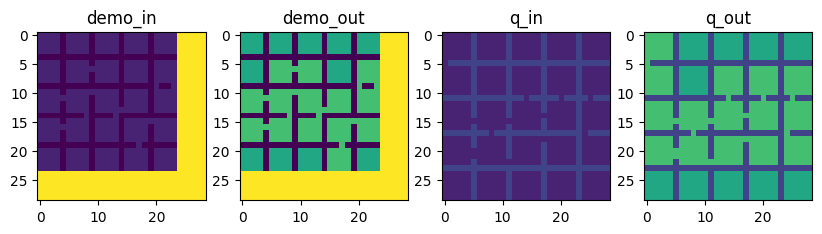

GATE L0: 14935 episodes/s (need >= 50)


In [5]:
ep = sample_episodes(TRAIN_CACHE, TRAIN_TIDS, B=8)
B, ND, Hb, Wb = ep["demo_in"].shape
assert ep["q_in"].shape == (8, Hb, Wb) and ep["demo_mask"].shape == (8, ND)
assert ep["q_out"].max() <= PAD_ID
# augmentation consistency: demo and query of one episode share the color perm (visual spot check)
fig, ax = plt.subplots(1, 4, figsize=(10, 3))
for a, k_ in zip(ax, ("demo_in", "demo_out", "q_in", "q_out")):
    a.imshow(ep[k_][0].cpu() if k_.startswith("q") else ep[k_][0, 0].cpu(), vmin=0, vmax=10)
    a.set_title(k_)
plt.show()
# throughput
torch.cuda.synchronize(); t0 = time.time()
for _ in range(20): sample_episodes(TRAIN_CACHE, TRAIN_TIDS, B=64)
torch.cuda.synchronize()
eps_per_s = 20 * 64 / (time.time() - t0)
print(f"GATE L0: {eps_per_s:.0f} episodes/s (need >= 50)")
assert eps_per_s >= 50